## Time-frequency Analysis

EEG activity is divided into frequency bands that respond to perceptual and cognitive events in distinct ways and tend to divide labor into sub-processes with particular footprint in time or space. A deeper understanding of the relationship between EEG and behavior can be gained by studying 

In [62]:
import mne
from glob import glob as ls
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

### Configuration
Again, we will be working with the trial segmented data. Some highly specific cases may require that you first apply frequency filters and then segment the data (e.g. if working with short intervals), but most analyses can done this way. Below we're selecting the stimulus-locked EEG data.

In [58]:
files = [f for f in sorted(ls("Data/s03/*stim-epo.fif.gz"))];files

['Data/s03/dmss03_stim-epo.fif.gz']

Parameters to choose for this analysis are the frequencies to analyze (usualy defined as a range, either in fixed steps or logarithmically as below). And we again define the conditions we're interested in (reminder that this can be chosen more flexibly than we did below).

In [ ]:
# below freqs is defined as a logarithmic space on 1-60Hz, projected to integers, then 1Hz and 2Hz are dropped
freqs = np.unique(np.round(np.exp(np.linspace(0,np.log(60)))))[2:]
# we want to separate analysis by conditions - which are defined as strings that can operate on the Epochs object
conditions = ['size1','size2','size4']

### Computation
Here, we compute the spectral power in the frequencies of interest. There are several methods that can achieve this goal, we chose the multitaper method which applies FFT at varying filter length. Other options in MNE are Morlet wavelets and the Stockwell method.

Since this is a computationally expensive step, we save the results. In this case we save the trial-averaged data to save space, but you may choose to save each spectral power for each trial.

In [59]:
tfrs = {k:[] for k in conditions}
for f in files:
    epochs = mne.read_epochs(f,preload=True)
    epochs.info['bads'] = []
    for c in conditions:
        tfr = epochs[c].compute_tfr('multitaper',freqs,decim=5).crop(tmin=-.4,tmax=1.2)
        tfr.average().save(f[:-11]+f"_{c}-tfr.h5",overwrite=True) # optionally save per-trial data
        tfrs[c].extend([tfr.average()])
# we don't apply baselines to the results above, because we may need to use different baselines for different applications

Reading /Users/fbaumg/Documents/Obsidian/Courses/PS329/Data/s03/dmss03_stim-epo.fif.gz ...
    Found the data of interest:
        t =    -700.00 ...    1700.00 ms
        0 CTF compensation matrices available
Adding metadata with 5 columns
690 matching events found
No baseline correction applied
0 projection items activated
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


### Analysis
Now we visualize the results - first, we investigate the time course of spectral power averaged over all trials of the 3 defined conditions. In the plots, the x-axis shows trial time and the y-axis shows frequencies. Sincer the data is baselined, the colors indicate an increase (red) or decrease (blue) compared to the time before the stimulus.

Immediately we notice the wide-spread decrease in power in higher frequencies

Applying baseline correction (mode: ratio)
Applying baseline correction (mode: ratio)
Applying baseline correction (mode: ratio)


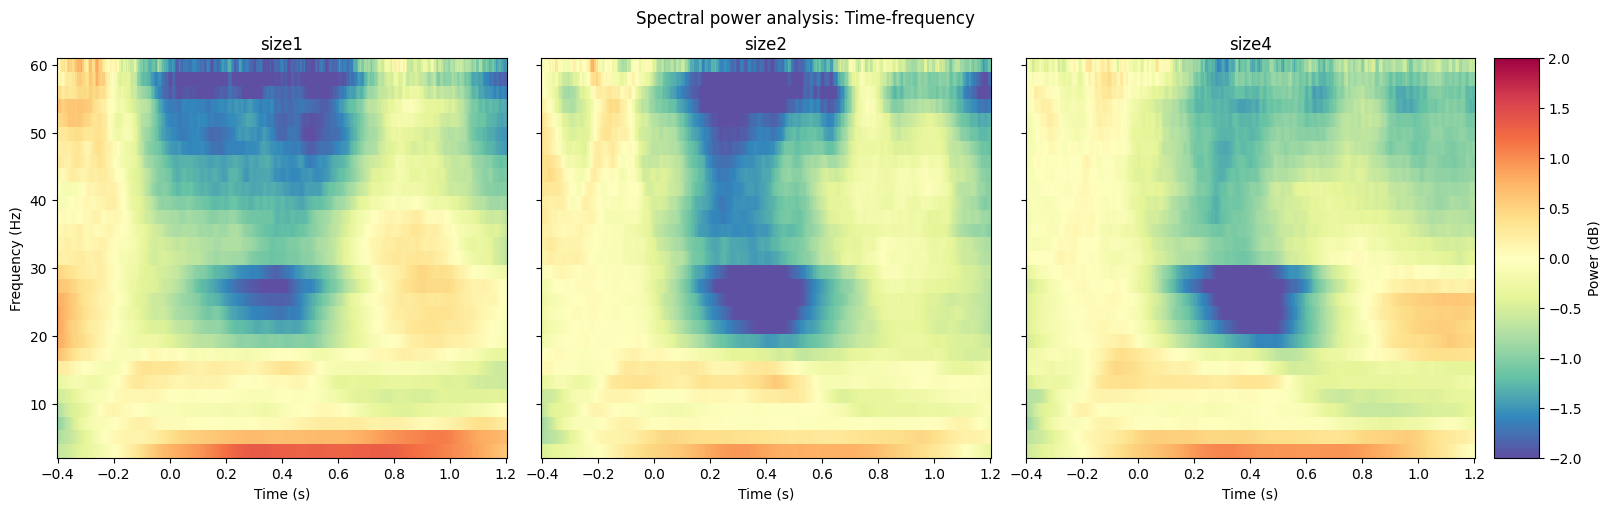

In [65]:
num = len(conditions)
fig = plt.figure(figsize=(5*num+1, 5), layout="constrained")
gs = fig.add_gridspec(1, num+1, width_ratios=[10]*num + [1])
axs_tfr = [fig.add_subplot(gs[0, a]) for a in range(num)]
ax_cbar = fig.add_subplot(gs[0, num])

for i, (c, tf) in enumerate(tfrs.items()):
    tf[0].plot(picks='eeg',combine='mean',baseline=(-.3,-.1),mode='ratio',vlim=(-2,2),dB=True,
        axes=axs_tfr[i],show=False,cmap='Spectral_r', colorbar=False)
    axs_tfr[i].set_title(c)
    if i > 0:
        axs_tfr[i].set_ylabel("")
        axs_tfr[i].set_yticklabels([])
im = axs_tfr[0].images[0]
fig.colorbar(im, cax=ax_cbar, orientation='vertical', label='Power (dB)');
fig.suptitle("Spectral power analysis: Time-frequency");

Applying baseline correction (mode: logratio)
No baseline correction applied
Applying baseline correction (mode: logratio)
No baseline correction applied
Applying baseline correction (mode: logratio)
No baseline correction applied


Text(0.5, 0.98, 'Spectral Power Analysis: Topographies')

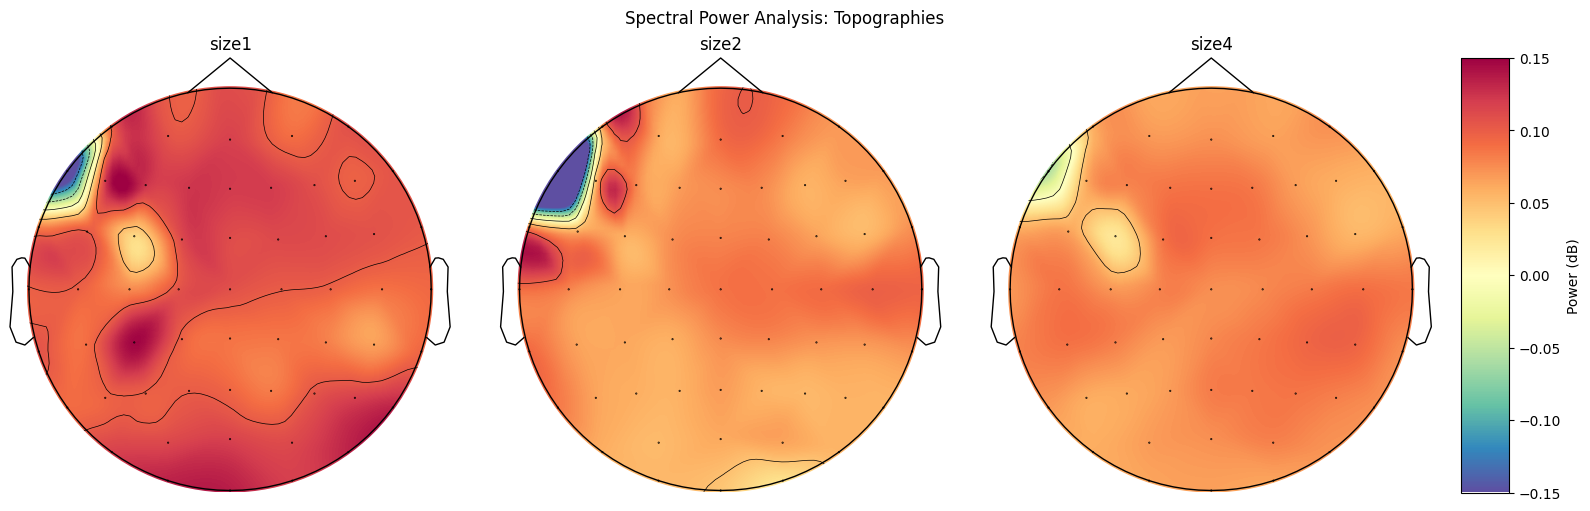

In [66]:
num = len(conditions)
fig = plt.figure(figsize=(5*num+1, 5), layout="constrained")
gs = fig.add_gridspec(1, num+1, width_ratios=[10]*num + [1])
axs_tfr = [fig.add_subplot(gs[0, a]) for a in range(num)]
ax_cbar = fig.add_subplot(gs[0, num])

for i, (c, tf) in enumerate(tfrs.items()):
    tf[0].copy().apply_baseline((-.3,-.1),mode='logratio').plot_topomap(
        vlim=(-.15,.15),tmin=.3,tmax=.5,fmin=2,fmax=4,cmap='Spectral_r',
    axes=axs_tfr[i],show=False,colorbar=False);
    axs_tfr[i].set_title(c)
im = axs_tfr[0].images[0]
fig.colorbar(im, cax=ax_cbar, orientation='vertical', label='Power (dB)');
fig.suptitle("Spectral Power Analysis: Topographies")